In [1]:
import geopandas as gpd
import pandas as pd
from useful_functions import *
import pickle
import time
import resource_bifiltration as RB
import importlib
import os

import sys
from contextlib import redirect_stdout
from datetime import datetime
import numpy as np
import networkx as nx

import matplotlib as mpl
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

plt.rc('text', usetex=True)
plt.rc('font', family='serif')

plt.rcParams['font.size'] = 18

In [2]:
qs = np.arange(400, 2000,300)
rs = np.arange(0.5, 2.01, 0.3)*1000
rs = rs[::-1]

score_col = 'Total Stars'

thresh_type = 'areaperc'
len_thresh = 0.2

all_params = {
              'rs': rs, 
              'qs': qs, 
              'quality score col': score_col, 
              'threshold type': thresh_type, 
              'threshold': len_thresh}

now = datetime.now()
strdate = now.strftime("%Y-%m-%d")

In [3]:
all_params

{'rs': array([2000., 1700., 1400., 1100.,  800.,  500.]),
 'qs': array([ 400,  700, 1000, 1300, 1600, 1900]),
 'quality score col': 'Total Stars',
 'threshold type': 'areaperc',
 'threshold': 0.2}

In [4]:
path_to_files = 'geographic_data/'
results_folder = f'Results_Pubs_Resource/'

fileextra = f'_{thresh_type}_{str(len_thresh).replace('.', 'p')}'

blocks = gpd.read_file(path_to_files + 'chicago_blocks.shp')
ratings = pd.read_csv(path_to_files + "Bars_and_Pubs_Reviews_FINAL.csv")
D = np.load('geographic_data/pubs_distances_L1_NEW.npy')

blocks = blocks.to_crs('EPSG:26916')

In [5]:
ratings['Total Stars'] = ratings['rating'] * ratings['user_ratings_total']

In [6]:
G_adj = adjacency_graph(blocks)
rb = RB.ResourceBifiltration(scores = ratings[score_col].values, D = D, G = G_adj)

In [7]:
if len(qs) != len(rs):
    print("INEQ")

In [8]:
########## Make sure folders exist ##########
os.makedirs(f'{results_folder}/{strdate}', exist_ok=True)
results_folder = results_folder + f"/{strdate}/"

In [9]:
# Save log with outputs from running TrackedComponentCollection
with open(f'{results_folder}/PUBS_resource_LOG{fileextra}.txt', 'w') as f:
    with redirect_stdout(f):
        print("Running code to generate TCC.")
        print(f"r values: {rs}")
        print(f"q values: {qs}")
        print("Code started at:", now.strftime("%Y-%m-%d_%H:%M:%S"))
        TCC = RB.TrackedComponentCollection(rb, rs, qs, len_thresh = len_thresh, blocks = blocks, thresh_type=thresh_type)

# Save TCC produced from TrackedComponentCollection
with open(f'{results_folder}/PUBS_resource_TCC{fileextra}.pkl', 'wb') as file:
    pickle.dump(TCC, file)

# Save params used for this run for reproducibility
with open(f'{results_folder}/PUBS_resource_PARAMS{fileextra}.pkl', 'wb') as file:
    pickle.dump(all_params, file)

In [10]:
print("Starting postprocess merging...")
########## Postprocess Merging ##########
G = construct_graph(TCC)

# Components that need to be merged
big_Cs = [C for C in nx.connected_components(G) if len(C) > 1]

# Components that don't need to be merged but save for later
small_cs = [C for C in nx.connected_components(G) if len(C) == 1]
small_TCs = [next(iter(i)) for i in small_cs]

# merge all components that are in the connected component 
merged_TCs = []

# Loop through the components C of the graph G. Each of these is a set of tracked components we want to merge
for i, C in enumerate(big_Cs):
    # print(f"Set {i}")
    # Initialize merged_TC to the first TC in C
    # print("Initializing with TC #0")
    C = list(C)
    merged_TC = C[0]
    
    # Merge in the others one by one
    for j, TC in enumerate(C[1:]):
        # print(f"Merging in TC #{j + 1}")
        merged_TC = TCC.get_merged_tracked_comp(merged_TC, TC)
    merged_TCs.append(merged_TC)
    # print("------------------------------------\n")


all_TCs = merged_TCs+small_TCs

Starting postprocess merging...


In [11]:
with open(f'{results_folder}/PUBS_resource_post_initial_merge{fileextra}.pkl', 'wb') as file:
    pickle.dump(all_TCs, file)

# Final Merging

In [12]:
mergethreshold = 0.9
fileextra += f'_{str(mergethreshold).replace('.', 'p')}' 

# Post process merging
overlapamt = np.zeros([len(all_TCs),len(all_TCs)])

for i, TC1 in enumerate(all_TCs):
        
        all_sets1 = list(TC1.C_reps.values())
        TC1_max_rep = set.union(*all_sets1)
            
        for j, TC2 in enumerate(all_TCs):
            if i<j:
                all_sets2 = list(TC2.C_reps.values())
                TC2_max_rep = set.union(*all_sets2)

                amt_1_in_2 = len(TC2_max_rep.intersection(TC1_max_rep)) / len(TC2_max_rep)
                amt_2_in_1 = len(TC1_max_rep.intersection(TC2_max_rep)) / len(TC1_max_rep)

                overlapamt[i,j] = max(amt_1_in_2, amt_2_in_1)
                overlapamt[j,i] = overlapamt[i,j]
            elif i == j:
                 overlapamt[i,j] = 1

G = nx.Graph()
G.add_nodes_from(range(len(all_TCs)))

# Only look at upper triangle to avoid duplicate edges
rows, cols = np.where(np.triu(overlapamt, k=1) > mergethreshold)

edges = [(r, c, overlapamt[r, c]) for r, c in zip(rows, cols)]
G.add_weighted_edges_from(edges)

singletons = [node for node, degree in G.degree() if degree == 0]
G.remove_nodes_from(singletons)

nomerge_needed_dicts = []
for tc in [all_TCs[i] for i in singletons]:
        all_sets = list(tc.C_reps.values())
        max_rep = set.union(*all_sets)
        lifetime = len(tc.C_reps.keys())
        plotting_dict = {'maxrep': max_rep, 'lifetime': lifetime}

        nomerge_needed_dicts.append(plotting_dict)


# Get connected components as subgraphs
components = [G.subgraph(c) for c in nx.connected_components(G)]

# # Classify components into three lists
# non_trees = [c for c in components if not nx.is_tree(c)]
# pairs     = [c for c in components if nx.is_tree(c) and c.number_of_nodes() == 2]
# trees     = [c for c in components if nx.is_tree(c) and c.number_of_nodes() != 2]

print(f"Number of components: {len(components)}")
# print(f"Number of non-trees:  {len(non_trees)}")
# print(f"Number of pairs:      {len(pairs)}")
# print(f"Number of trees:      {len(trees)}")

Number of components: 12


In [14]:
colors=['C0','C1','C2','C3','C4','C5','C6','C7','C8','C9']
colors = colors+colors+colors+colors+colors+colors+colors+colors+colors
for i, c in enumerate(components):
    tccomp = [all_TCs[i] for i in c.nodes]
    fig, ax = plt.subplots(1,3, figsize=(10,3))
    # new_tc = merge_dicts_v2(*[TC.C_reps for TC in tccomp])
    nodecolors = []
    for j,tc in enumerate(tccomp):
        all_sets = list(tc.C_reps.values())
        max_rep = set.union(*all_sets)

        currentmaxrep = blocks[blocks.index.isin(max_rep)]
        union_mr = currentmaxrep.union_all()
        mr = gpd.GeoSeries(union_mr, crs=blocks.crs)

        mr.plot(ax=ax[1], edgecolor=colors[j], facecolor='none', label=j)
        nodecolors.append(colors[j])

    new_tc = merge_dicts_v2(*[TC.C_reps for TC in tccomp])
    all_sets = list(new_tc.values())
    max_rep = set.union(*all_sets)
    currentmaxrep = blocks[blocks.index.isin(max_rep)]
    union_mr = currentmaxrep.union_all()
    mr = gpd.GeoSeries(union_mr, crs=blocks.crs)
    mr.plot(ax=ax[0], color='pink', label=j)

    ax[0].axis('off')
    ax[1].axis('off')

    nx.draw(c,ax=ax[2], node_color=nodecolors, with_labels=False, node_size=70)

    plt.savefig(f'{results_folder}/TEMP/Component{i}.png', bbox_inches = 'tight', dpi = 300)
    plt.close()

In [15]:
merged_dicts = []
for c in components:

    tccomp = [all_TCs[i] for i in c.nodes]
    new_tc = merge_dicts_v2(*[TC.C_reps for TC in tccomp])
    all_sets = list(new_tc.values())
    max_rep = set.union(*all_sets)
    lifetime = len(new_tc.keys())
    plotting_dict = {'maxrep': max_rep, 'lifetime': lifetime}
            
    merged_dicts.append(plotting_dict)

all_dicts = nomerge_needed_dicts + merged_dicts

with open(f'{results_folder}/PUBS_resource_final_step_{fileextra}.pkl', 'wb') as file:
    pickle.dump(all_dicts, file)

## Plots

In [17]:
TCC = all_dicts

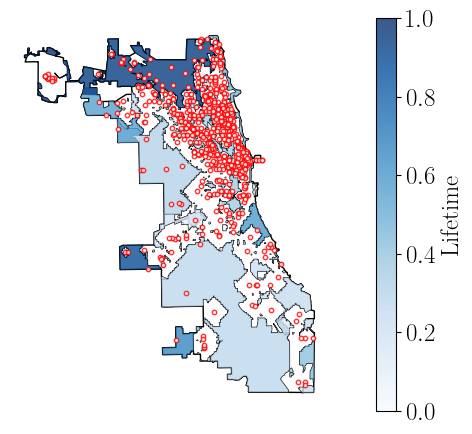

In [18]:
########## All Maximal Components, colored by range ##########
cmap = mpl.colormaps['Blues']
norm = mpl.colors.Normalize(vmin=0, vmax=1)  # scale from 0 to 1

plottingalph = 0.8

geometry = [Point(xy) for xy in zip(ratings['lng_g'], ratings['lat_g'])]

geo_df = gpd.GeoDataFrame(ratings, #specify our data
                          geometry=geometry, crs='EPSG:4326')

geo_df = geo_df.to_crs('EPSG:26916')

union_geom = blocks.union_all()
boundary = gpd.GeoSeries(union_geom.boundary)

fig, ax = plt.subplots(figsize=(10,5))
boundary.plot(ax=ax, color='black', linewidth=1)

sorted_comps = sorted(TCC, key=lambda x: x["lifetime"], reverse=False)

geo_df.plot(ax=ax, color='r', marker='o', markersize=10, zorder=1000, alpha=0.8, facecolors='white') #, edgecolors='black')

# sorted_TCs = [x for (x,_,_) in sorted(zip(all_TCs,normalized_values,color_mapvals), key=lambda pair: pair[1])]
# sorted_color_mapvals = [z for (_,_,z) in sorted(zip(all_TCs,normalized_values,color_mapvals), key=lambda pair: pair[1])]
# print(sorted_TCs)

for i, TC in enumerate(sorted_comps): #enumerate(all_TCs):
    maxrep = TC['maxrep']
    lifetime = TC['lifetime']/ (len(rs) * len(qs))

    currentmaxrep = blocks[blocks.index.isin(maxrep)]
    union_mr = currentmaxrep.union_all()
    mr = gpd.GeoSeries(union_mr, crs=blocks.crs)

    mr.plot(ax=ax, color=cmap(lifetime), alpha=plottingalph, zorder=(i+1))

    mr.boundary.plot(ax=ax, color='k', linewidth=0.75) #, linestyle='dashed')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for older versions of matplotlib
cbar = fig.colorbar(sm, ax=ax, alpha=plottingalph) 
cbar.set_label('Lifetime')

plt.tight_layout()
plt.axis('off')

plt.savefig(f'{results_folder}/PUBS_resource_Maxrep_ALL_lifetime{fileextra}.png', bbox_inches = 'tight', dpi = 300)

In [9]:
pwd

'/Users/stymochko/Library/CloudStorage/Dropbox/Dropbox/Research/Postdoc_UCLA/ResourceCoverage/resource-coverage'

In [22]:
with open(f'Results_Pubs_RESOURCE/2025-12-19/PUBS_RESOURCE_2025-12-19_TCC_postmerge_areaperc_0p{int(len_thresh*10)}.pkl', 'rb') as file:
    all_TCs = pickle.load(file)

In [54]:
# for i, C in enumerate(big_Cs):
#     plt.title(f"Set {i} of Overlapping Tracked Components")
#     H = G.subgraph(C)
#     pos = nx.spring_layout(H)
#     weights = [G[u][v]['weight'] for u,v in H.edges()]
#     nx.draw_networkx_nodes(H, pos)
#     nx.draw_networkx_edges(H, pos, edgelist= H.edges(), width = weights)
#     edge_labels = nx.get_edge_attributes(H, "weight")
#     node_labels = {u : len(u.term_coords) for u in H.nodes()}
#     nx.draw_networkx_labels(H, pos, node_labels)
#     nx.draw_networkx_edge_labels(H, pos, edge_labels)
#     plt.savefig(f"Figures/{fig_folder}/graph_set{i}.png", bbox_inches = 'tight', dpi = 100)
#     plt.close()

In [18]:
for i,TC in enumerate(all_TCs):
    if len(TC.C_reps.keys()) > 1: 
        TC.plot_components_v2(blocks,rs,qs)
        plt.savefig(f'{results_folder}/ComponentFigs/set{i}{fileextra}.png', bbox_inches = 'tight', dpi = 300)
        
        plt.close()

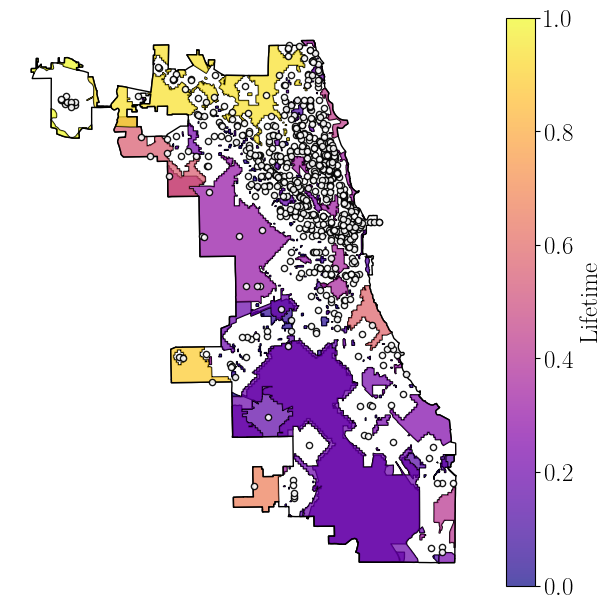

In [23]:
import matplotlib as mpl

from shapely.geometry import Point, Polygon

geometry = [Point(xy) for xy in zip(ratings['lng_g'], ratings['lat_g'])]

geo_df = gpd.GeoDataFrame(ratings, #specify our data
                          geometry=geometry, crs='EPSG:4326')

geo_df = geo_df.to_crs('EPSG:26916')

cmap = mpl.colormaps['plasma']
norm = mpl.colors.Normalize(vmin=0, vmax=1)  # scale from 0 to 1

# Compute normalized color values
raw_values = np.array([len(TC.C_reps.keys()) for TC in all_TCs])
max_value = len(rs) * len(qs)
normalized_values = raw_values / max_value
color_mapvals = [cmap(v) for v in normalized_values]

union_geom = blocks.union_all()
boundary = gpd.GeoSeries(union_geom.boundary)

fig, ax = plt.subplots(figsize=(7,7))
boundary.plot(ax=ax, color='black', linewidth=1)

geo_df.plot(ax=ax, color='white', marker='o', zorder=1000, edgecolors='black', alpha=0.9, markersize=20)

sorted_TCs = [x for (x,_,_) in sorted(zip(all_TCs,normalized_values,color_mapvals), key=lambda pair: pair[1])]
sorted_color_mapvals = [z for (_,_,z) in sorted(zip(all_TCs,normalized_values,color_mapvals), key=lambda pair: pair[1])]
# print(sorted_TCs)

for i, TC in enumerate(sorted_TCs): #enumerate(all_TCs):
    all_sets = list(TC.C_reps.values())
    TC.max_rep = set.union(*all_sets)

    maxrep_union = blocks[blocks.index.isin(TC.max_rep)].union_all()
    maxrep_boundary = gpd.GeoSeries(maxrep_union.boundary) 

    maxrep_boundary.plot(ax=ax, color='k', linewidth=1, zorder=1) #, linestyle='dashed')

    gpd.GeoSeries(maxrep_union, crs='EPSG:26916').plot(ax=ax, color=sorted_color_mapvals[i], zorder=1, alpha=0.7, edgecolor='none')

    blocks[blocks.index.isin(TC.max_rep)].plot(ax=ax, color='none', linewidth=0)


sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for older versions of matplotlib
cbar = fig.colorbar(sm, ax=ax, alpha=0.7, shrink=0.95)
# cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Lifetime')

plt.tight_layout()
plt.axis('off')

plt.savefig(f'Results_Pubs_RESOURCE/Maxrep_ALL_range_wPubs_resource_areaperc0p{int(len_thresh*10)}.png', bbox_inches = 'tight', dpi = 400)

In [ ]:
keep_listkeep_list = []
for i, TC1 in enumerate(sorted_TCs): #enumerate(all_TCs):
    all_sets1 = list(TC1.C_reps.values())
    TC1_max_rep = set.union(*all_sets1)
    for j, TC2 in enumerate(sorted_TCs):
        if j> i:
            all_sets2 = list(TC2.C_reps.values())
            TC2_max_rep = set.union(*all_sets2)
            if TC2_max_rep.issubset(TC1_max_rep):
                print('2 subset of 1')
                keep_list.append([TC1_max_rep, TC2_max_rep])
            if TC1_max_rep.issubset(TC2_max_rep):
                print('1 subset of 2')
                keep_list.append([TC1_max_rep, TC2_max_rep])

<Axes: >

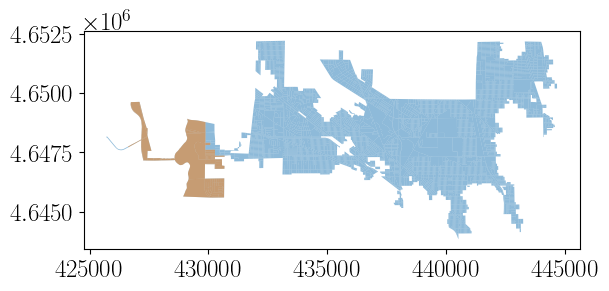

In [35]:
fig, ax = plt.subplots()
blocks[blocks.index.isin(keep_list[0][0])].plot(ax=ax,alpha=0.5)
blocks[blocks.index.isin(keep_list[0][1])].plot(ax=ax,alpha=0.5,color='C1')

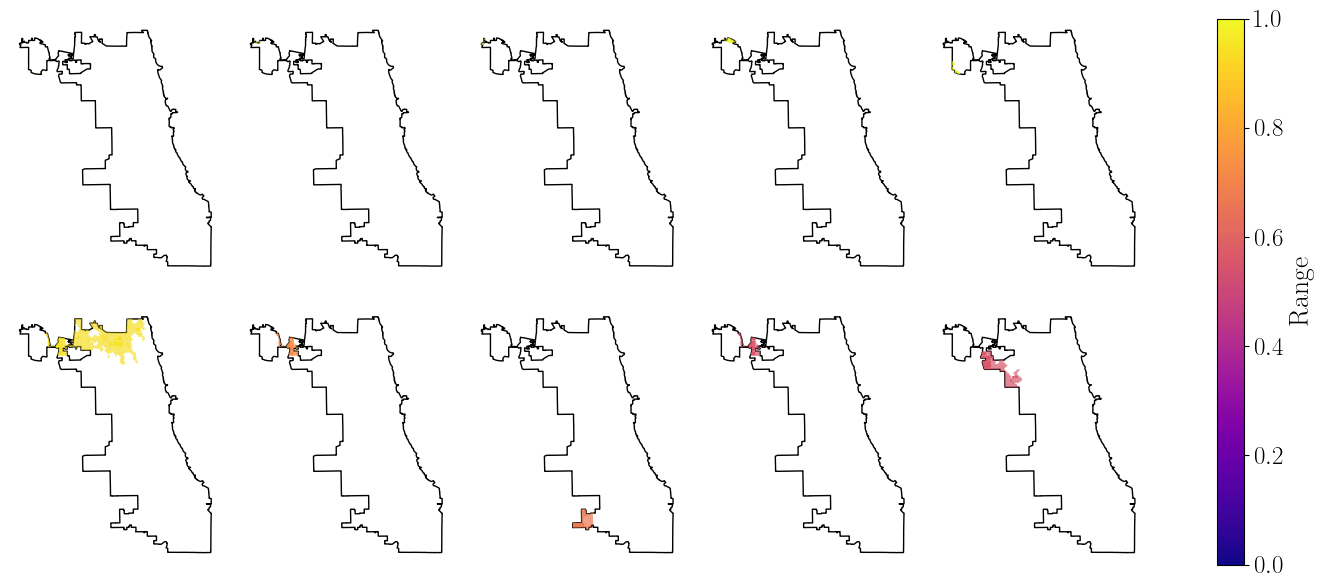

In [16]:
import matplotlib as mpl

plt.rcParams['font.size'] = 18

cmap = mpl.colormaps['plasma']
norm = mpl.colors.Normalize(vmin=0, vmax=1)  # scale from 0 to 1

# Compute normalized color values
raw_values = np.array([len(TC.C_reps.keys()) for TC in all_TCs])
max_value = len(rs) * len(qs)
normalized_values = raw_values / max_value
color_mapvals = [cmap(v) for v in normalized_values]

union_geom = blocks.union_all()
boundary = gpd.GeoSeries(union_geom.boundary)

fig, ax = plt.subplots(2,5,figsize=(15,6))
# boundary.plot(ax=ax, color='black', linewidth=1)

sorted_TCs = [x for (x,_,_) in sorted(zip(all_TCs,normalized_values,color_mapvals), key=lambda pair: pair[1])]
sorted_normvals = [y for (_,y,_) in sorted(zip(all_TCs,normalized_values,color_mapvals), key=lambda pair: pair[1])]
sorted_color_mapvals = [z for (_,_,z) in sorted(zip(all_TCs,normalized_values,color_mapvals), key=lambda pair: pair[1])]

sorted_TCs = sorted_TCs[::-1]
sorted_color_mapvals = sorted_color_mapvals[::-1]
sorted_normvals = sorted_normvals[::-1]

axes = ax.flatten()

for i, TC in enumerate(sorted_TCs[:10]): 
    all_sets = list(TC.C_reps.values())
    TC.max_rep = set.union(*all_sets)

    boundary.plot(ax=axes[i], color='black', linewidth=1)

    blocks[blocks.index.isin(TC.max_rep)].plot(ax=axes[i], color=sorted_color_mapvals[i], legend=True, zorder=(i+1))
    # axes[i].set_title(f'Range: {round(sorted_normvals[i],3)}', fontsize=13)

    axes[i].axis('off')

plt.tight_layout()

# plt.suptitle('Top 10 Maximal Components Based on Range')
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for older versions of matplotlib
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Range', fontsize=20)

# plt.tight_layout()
# plt.axis('off')

plt.savefig(f'{results_folder}/Maxrep_SepFigs_range{fileextra}.png', bbox_inches = 'tight', dpi = 300)

# Extra figures (superlevelsets and bifiltration examples)

In [17]:
radlist = [500,1500,2500,3500,4500,5500,6500,7500,8500,1400,800,2000]#list(rs) + list(np.arange(900, 0, -100)) + [2000]#[50, 60, 70, 80, 90, 100, 110] #[500, 750, 1000, 1250, 1500, 1750]
collist = [f'filtvalue_{r}' for r in radlist]
for rad in radlist:

    # calculate sum of scores for each block
    for j in range(rb.num_blocks):
        blocks.loc[j,f'filtvalue_{rad}'] = rb.f(j,rad)

In [18]:
radlist

[500, 1500, 2500, 3500, 4500, 5500, 6500, 7500, 8500, 1400, 800, 2000]

In [19]:
r1, r2, r3 = 2000, 1400, 800
q1, q2, q3 = 0, 1000, 2000

blocks[f'{r1}_{q1}'] = (blocks[f'filtvalue_{r1}']<=q1)*1
blocks[f'{r1}_{q2}'] = (blocks[f'filtvalue_{r1}']<=q2)*1
blocks[f'{r1}_{q3}'] = (blocks[f'filtvalue_{r1}']<=q3)*1

blocks[f'{r2}_{q1}'] = (blocks[f'filtvalue_{r2}']<=q1)*1
blocks[f'{r2}_{q2}'] = (blocks[f'filtvalue_{r2}']<=q2)*1
blocks[f'{r2}_{q3}'] = (blocks[f'filtvalue_{r2}']<=q3)*1

blocks[f'{r3}_{q1}'] = (blocks[f'filtvalue_{r3}']<=q1)*1
blocks[f'{r3}_{q2}'] = (blocks[f'filtvalue_{r3}']<=q2)*1
blocks[f'{r3}_{q3}'] = (blocks[f'filtvalue_{r3}']<=q3)*1

In [20]:
collist_bif = [f'{r1}_{q1}', f'{r1}_{q2}', f'{r1}_{q3}',
               f'{r2}_{q1}', f'{r2}_{q2}', f'{r2}_{q3}',
               f'{r3}_{q1}', f'{r3}_{q2}', f'{r3}_{q3}']

In [21]:
union_geom = blocks.union_all()
boundary = gpd.GeoSeries(union_geom.boundary)

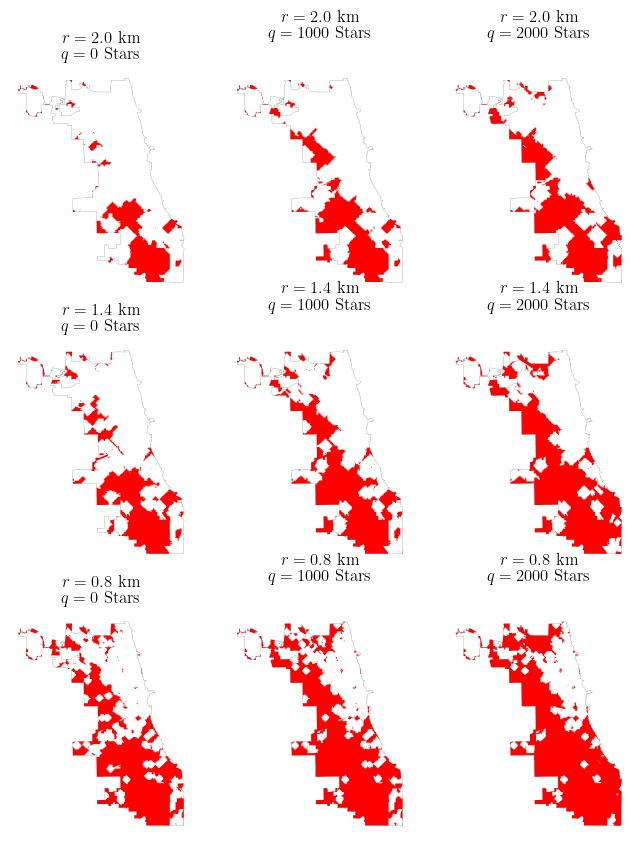

In [22]:
fig, axs = plt.subplots(3, 3, figsize=(8, 10))

# Flatten the axes array for easy iteration
axs = axs.flatten()

# cmap = 'Greens'

# Plot each subplot and store the image for colorbar reference
for ax, c in zip(axs, collist_bif):
    boundary.plot(ax=ax, color='k', linewidth=0.1)

    bblocks = blocks[blocks[c] == 1]

    polygon = bblocks.geometry.union_all()
    gdfbblocks = gpd.GeoDataFrame(geometry=[polygon], crs=blocks.crs)

    gdfbblocks.plot(ax=ax, facecolor='red') #, linewidth=1, cmap=cmap, vmin=0, vmax=1)

    # blocks.plot(ax=ax, column=c, cmap=cmap) #, vmin=0, vmax=1) 
    r = c.split('_')[0]
    q = c.split('_')[1]
    rkm=round(int(r)/1000,1)
    ax.set_title(f'$r={rkm}$ km\n$q={q}$ Stars', size=12)
    
    ax.axis('off')

# # Add a single shared colorbar to the right of the subplots
# fig = ax.get_figure()
# cax = fig.add_axes([0.95, 0.1, 0.03, 0.8])

# sm = plt.cm.ScalarMappable(cmap=cmap, norm=log_norm) #plt.Normalize(vmin=vmin, vmax=vmax))
# sm._A = []
# cbar = fig.colorbar(sm, cax=cax, label=f'Acres', pad=0)

# cbar.ax.tick_params(labelsize=12) 
# cbar.set_label('Acres', size=12)

# plt.tight_layout()

if baseline:
    plt.close()
else:
    plt.savefig(f'{results_folder}/Superlevel_Sets_PUBS.png', bbox_inches = 'tight', dpi = 300)

In [23]:
radplots = [500,1500,2500,3500,4500,5500,6500,7500,8500]
plotcollist = [f'filtvalue_{r}' for r in radplots]

vmin = min(min([min(blocks[col]) for col in plotcollist]),0)
vmax = max([max(blocks[col]) for col in plotcollist])

import matplotlib.colors as colors

log_norm = colors.LogNorm(vmin=vmin, vmax=vmax)

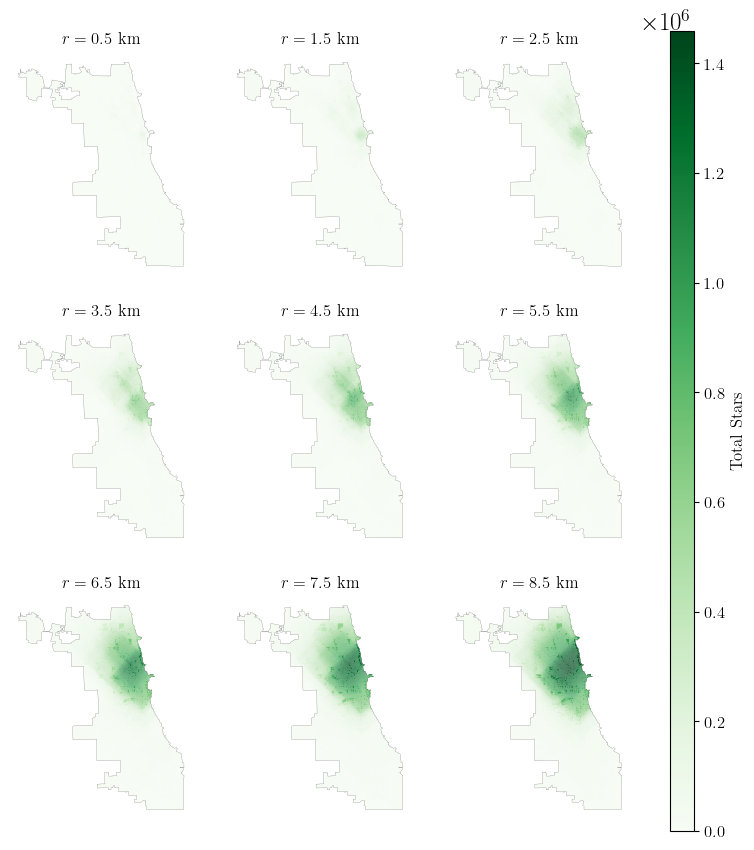

In [24]:
### Create the 2x3 subplot grid
fig, axs = plt.subplots(3, 3, figsize=(8, 10))

# Flatten the axes array for easy iteration
axs = axs.flatten()

cmap = 'Greens'

# Plot each subplot and store the image for colorbar reference
for ax, r in zip(axs, radplots): #np.arange(3000,499, -500)): #radlist[::2]):
    boundary.plot(ax=ax,color='k', linewidth=0.1)
    blocks.plot(ax=ax, column=f'filtvalue_{r}', cmap=cmap, vmin=vmin, vmax=vmax) #, norm=log_norm)
    rkm = round(r/1000,1)
    ax.set_title(f'$r={rkm}$ km', size=12)
    
    ax.axis('off')

# Add a single shared colorbar to the right of the subplots
fig = ax.get_figure()
cax = fig.add_axes([0.95, 0.1, 0.03, 0.8])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, cax=cax, label=f'Total Stars', pad=0)

cbar.ax.tick_params(labelsize=12) 
cbar.set_label('Total Stars', size=12)

if baseline:
    plt.close()
else:
    plt.savefig(f'{results_folder}/f_rq_Examples_PubsGood.png', bbox_inches = 'tight', dpi = 300)